# Checkpointing and Persistence

This notebook shows how to keep a genetic search reproducible and recoverable. Long-running searches should be able to write intermediate checkpoints, save the fitted search object, and load it again later for inspection or prediction.

## Menu

1. [Create a compact classification problem](#Create-a-compact-classification-problem)
2. [Configure a search with checkpoints](#Configure-a-search-with-checkpoints)
3. [Fit with modern optimizer controls](#Fit-with-modern-optimizer-controls)
4. [Inspect checkpoint contents](#Inspect-checkpoint-contents)
5. [Save and reload the fitted search](#Save-and-reload-the-fitted-search)
6. [Clean up generated files](#Clean-up-generated-files)
7. [Practical notes](#Practical-notes)

## Create a compact classification problem

The breast cancer dataset is small enough for a tutorial, but it still has enough features for the optimizer to make meaningful choices.

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

from sklearn_genetic import GASearchCV
from sklearn_genetic.callbacks import ConsecutiveStopping, ModelCheckpoint, TimerStopping
from sklearn_genetic.plots import plot_fitness_evolution
from sklearn_genetic.schedules import ExponentialAdapter, InverseAdapter
from sklearn_genetic.space import Categorical, Continuous, Integer

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

X_train.shape, X_test.shape

((426, 30), (143, 30))

## Configure a search with checkpoints

`ModelCheckpoint` writes the current estimator configuration and logbook during the fit. This is useful for long runs, interrupted sessions, or for storing the generation history next to experiment artifacts.

The regular `save` and `load` methods are different: they persist the fitted `GASearchCV` object after training, so it can be restored later for prediction and analysis.

In [2]:
artifact_dir = Path("ga_artifacts")
artifact_dir.mkdir(exist_ok=True)

checkpoint_path = artifact_dir / "breast_cancer_ga_checkpoint.pkl"
saved_search_path = artifact_dir / "breast_cancer_ga_search.pkl"

param_grid = {
    "n_estimators": Integer(40, 160),
    "max_depth": Integer(2, 12),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Continuous(0.25, 1.0),
    "criterion": Categorical(["gini", "entropy", "log_loss"]),
    "class_weight": Categorical([None, "balanced"]),
}

warm_start_configs = [
    {
        "n_estimators": 80,
        "max_depth": 5,
        "min_samples_leaf": 2,
        "max_features": 0.7,
        "criterion": "gini",
        "class_weight": None,
    }
]

callbacks = [
    ModelCheckpoint(checkpoint_path),
    ConsecutiveStopping(generations=4, metric="fitness"),
    TimerStopping(total_seconds=180),
]

## Fit with modern optimizer controls

This example combines persistence with the newer 0.13.0 development controls: smart initial populations, warm-start seeds, adaptive probabilities, local refinement, diversity control, fitness sharing, caching, and automatic parallel execution.

In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = GASearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    cv=cv,
    scoring="roc_auc",
    param_grid=param_grid,
    population_size=12,
    generations=8,
    population_initializer="smart",
    warm_start_configs=warm_start_configs,
    crossover_probability=ExponentialAdapter(initial_value=0.85, end_value=0.45, adaptive_rate=0.08),
    mutation_probability=InverseAdapter(initial_value=0.18, end_value=0.55, adaptive_rate=0.12),
    local_search=True,
    local_search_top_k=2,
    local_search_steps=2,
    local_search_radius=0.12,
    diversity_control=True,
    diversity_threshold=0.2,
    diversity_stagnation_generations=3,
    diversity_mutation_boost=1.8,
    random_immigrants_fraction=0.15,
    fitness_sharing=True,
    sharing_radius=0.25,
    use_cache=True,
    parallel_backend="auto",
    n_jobs=-1,
    verbose=False,
    keep_top_k=4,
    refit=True,
)

search.fit(X_train, y_train, callbacks=callbacks)
search.best_params_, search.best_score_

Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl


Checkpoint save in ga_artifacts\breast_cancer_ga_checkpoint.pkl
INFO: ConsecutiveStopping callback met its criteria
INFO: Stopping the algorithm


({'n_estimators': 106,
  'max_depth': 7,
  'min_samples_leaf': 6,
  'max_features': 0.9835721697561455,
  'criterion': 'log_loss',
  'class_weight': 'balanced'},
 np.float64(0.9889760440958236))

In [4]:
y_pred = search.predict(X_test)
y_proba = search.predict_proba(X_test)[:, 1]

pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
).to_frame("test_score")

,test_score
accuracy,0.944056
balanced_accuracy,0.940042
roc_auc,0.994340


The fit statistics summarize how much work was done. They are useful when comparing runs with different population sizes, smart initialization, caching, local search, or diversity controls.

In [5]:
pd.Series(search.fit_stats_).to_frame("value")

,value
evaluated_candidates,184
unique_candidates,159
cross_validate_calls,159
cache_hits,25
duplicate_candidates,0
skipped_invalid_candidates,0
population_parallel_batches,9
population_serial_batches,0
random_immigrants,8
local_refinement_candidates,4


In [6]:
history = pd.DataFrame(search.history)
history[
    [
        "gen",
        "fitness",
        "fitness_max",
        "unique_individual_ratio",
        "genotype_diversity",
        "stagnation_generations",
    ]
].tail()

,gen,fitness,fitness_max,unique_individual_ratio,genotype_diversity,stagnation_generations
3,3,0.986176,0.988022,0.666667,0.257576,2
4,4,0.985876,0.988022,0.833333,0.272727,3
5,5,0.986344,0.988128,0.833333,0.333333,4
6,6,0.986559,0.988976,0.833333,0.378788,0
7,7,0.985681,0.988976,0.916667,0.378788,1


C:\Users\dsdotpy\PycharmProjects\Sklearn-genetic-opt\sklearn_genetic\plots.py:48: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(x=range(len(estimator)), y=fitness_history, markers=True, palette=palette)


<Axes: title={'center': 'Fitness average evolution over generations'}, xlabel='generations', ylabel='fitness (score)'>

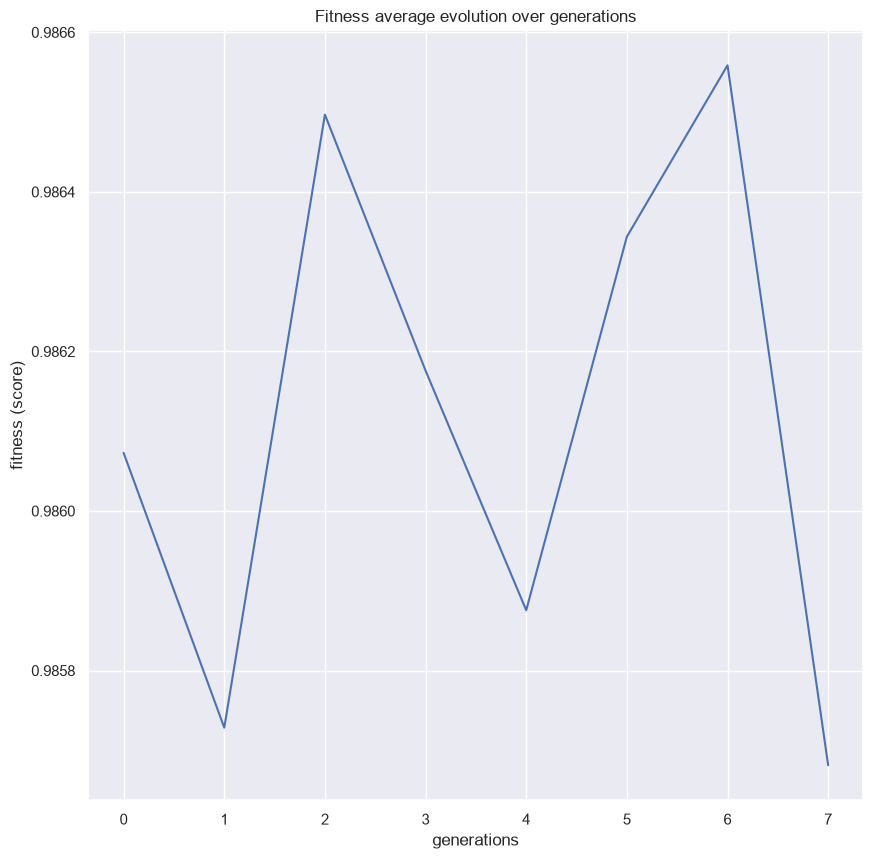

In [7]:
plot_fitness_evolution(search)

## Inspect checkpoint contents

The checkpoint callback stores a dictionary with two top-level keys: `estimator_state` and `logbook`. The state is intentionally lightweight and focuses on the search configuration; the logbook contains the generation records.

In [8]:
checkpoint = ModelCheckpoint(checkpoint_path).load()

checkpoint.keys(), len(checkpoint["logbook"])

(dict_keys(['estimator_state', 'logbook']), 8)

In [9]:
sorted(checkpoint["estimator_state"].keys())

['algorithm',
 'crossover_probability',
 'cv',
 'diversity_control',
 'diversity_mutation_boost',
 'diversity_stagnation_generations',
 'diversity_threshold',
 'estimator',
 'fitness_sharing',
 'generations',
 'local_search',
 'local_search_radius',
 'local_search_steps',
 'local_search_top_k',
 'mutation_probability',
 'param_grid',
 'population_size',
 'random_immigrants_fraction',
 'scoring',
 'sharing_alpha',
 'sharing_radius']

## Save and reload the fitted search

Use `save` after fitting when you want to preserve the full fitted search object. Reloading into a fresh `GASearchCV` instance restores the fitted estimator, history, best parameters, and prediction methods.

In [10]:
search.save(saved_search_path)

restored_search = GASearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    cv=cv,
    scoring="roc_auc",
    param_grid=param_grid,
)
restored_search.load(saved_search_path)

restored_predictions = restored_search.predict(X_test)

pd.Series(
    {
        "same_predictions": (restored_predictions == y_pred).all(),
        "restored_accuracy": accuracy_score(y_test, restored_predictions),
        "restored_best_score": restored_search.best_score_,
    }
).to_frame("value")

GASearchCV model successfully saved to ga_artifacts\breast_cancer_ga_search.pkl
GASearchCV model successfully loaded from ga_artifacts\breast_cancer_ga_search.pkl


,value
same_predictions,True
restored_accuracy,0.944056
restored_best_score,0.988976


## Clean up generated files

Keep this cell commented when you want to inspect the artifacts after the notebook finishes.

In [11]:
# for path in [checkpoint_path, saved_search_path]:
#     path.unlink(missing_ok=True)
# artifact_dir.rmdir()

## Practical notes

- Use `ModelCheckpoint` for progress recovery and audit trails during a fit.
- Use `save` and `load` for fitted search objects that need to be reused for prediction or later analysis.
- Store checkpoints outside temporary notebook directories for long runs.
- Keep `random_state` fixed across the estimator, splitter, and search inputs when you need repeatable artifacts.